In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from nnfabrik.builder import get_data, get_trainer

from sensorium2020_adapted import stacked_core_full_gauss_readout

random_seed = 42

device = "cuda:7"
torch.cuda.set_device(device)

In [2]:
import os

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": False,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)

In [3]:
model_config = {
    "pad_input": False,
    "stack": -1,
    "layers": 4,
    "input_kern": 9,
    "gamma_input": 6.3831,
    "gamma_readout": 0.0076,
    "hidden_kern": 7,
    "hidden_channels": 64,
    "depth_separable": True,
    "grid_mean_predictor": {
        "type": "cortex",
        "input_dimensions": 2,
        "hidden_layers": 1,
        "hidden_features": 30,
        "final_tanh": True,
    },
    "init_sigma": 0.1,
    "init_mu_range": 0.3,
    "gauss_type": "full",
    "shifter": False,
}

model_config["perspective"] = True

In [4]:
model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [5]:
model

FiringRateEncoder(
  (core): Stacked2dCore(
    (_input_weights_regularizer): LaplaceL2norm(
      (laplace): Laplace()
    )
    (features): Sequential(
      (layer0): Sequential(
        (conv): Conv2d(1, 64, kernel_size=(9, 9), stride=(1, 1), bias=False)
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer1): Sequential(
        (ds_conv): DepthSeparableConv2d(
          (in_depth_conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
          (spatial_conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=64)
          (out_depth_conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        )
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer2): Sequential(
        (ds_conv): DepthSeparableConv2d(
          (in_depth_conv): Conv2d(64, 64, kernel_size=(1, 1), s

In [6]:
trainer_fn = "sensorium.training.standard_trainer"

trainer_config = {
    "max_iter": 200,
    "verbose": False,
    "lr_decay_steps": 4,
    "avg_loss": False,
    "lr_init": 0.009,
    "track_training": False,
}

trainer_config["device"] = device

trainer = get_trainer(trainer_fn=trainer_fn, trainer_config=trainer_config)

In [7]:
validation_score, trainer_output, state_dict = trainer(
    model, dataloaders, seed=random_seed
)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")
Epoch 113: 100%|██████████| 252/252 [00:28<00:00,  8.94it/s]


In [8]:
validation_score

np.float32(0.35708994)

In [9]:
list(dataloaders['train'].keys())

['23343-5-17',
 '23964-4-22',
 '23656-14-22',
 '21067-10-18',
 '26872-17-20',
 '22846-10-16',
 '27204-5-13']

img shape: torch.Size([128, 36, 64])
perspective output shape: torch.Size([128, 36, 54])


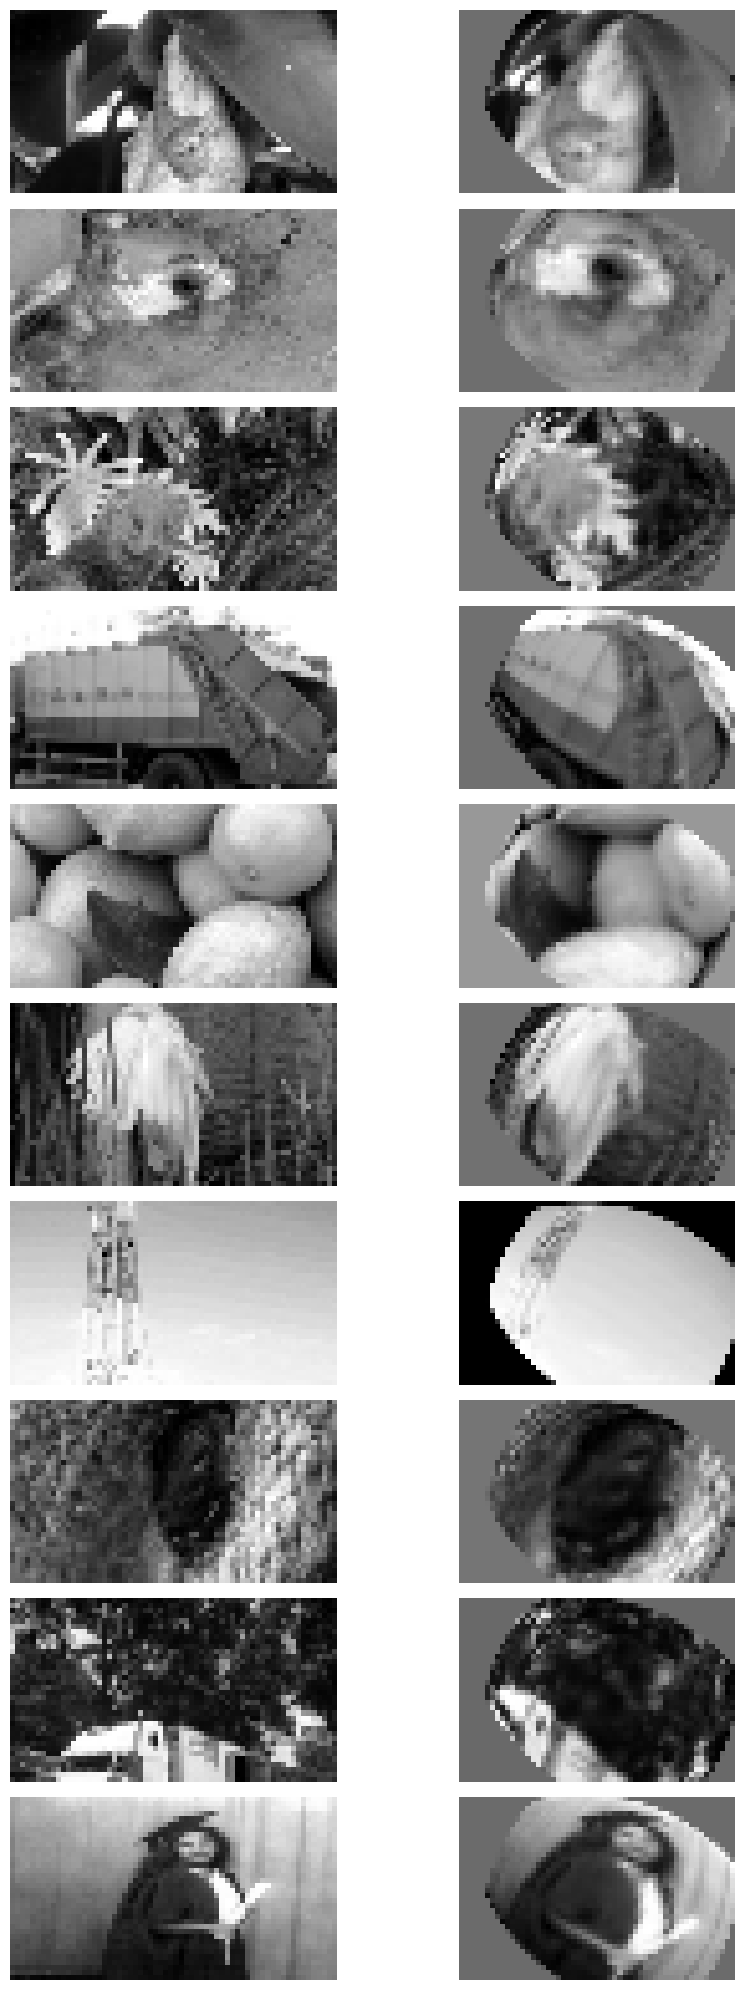

In [10]:
data_key = '23343-5-17'
batch = next(iter(dataloaders["train"][data_key]))

fig, ax = plt.subplots(10, 2, figsize=(10, 20))

imgs = batch.images[:, 0].detach().cpu()
out = model.perspective[data_key](batch.images, batch.pupil_center)[:, 0].detach().cpu()
print("img shape:", imgs.shape)
print("perspective output shape:", out.shape)

for i in range(10):
    ax[i, 0].imshow(imgs[i], cmap="gray")
    ax[i, 0].axis("off")
    ax[i, 1].imshow(out[i], cmap="gray")
    ax[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [11]:
from sensorium.utility import get_correlations, get_signal_correlations, get_fev
from sensorium.utility.measure_helpers import get_df_for_scores

model.eval();

In [12]:
single_trial_correlation = get_correlations(model, dataloaders, tier="test", device=device, as_dict=True)
print(single_trial_correlation)

{'23343-5-17': array([0.1541727 , 0.37457025, 0.21092035, ..., 0.38862512, 0.25337526,
       0.3428848 ], shape=(7334,), dtype=float32), '23964-4-22': array([0.29853836, 0.35941866, 0.20817843, ..., 0.39694604, 0.32743666,
       0.28239366], shape=(8098,), dtype=float32), '23656-14-22': array([0.25814736, 0.568715  , 0.37663156, ..., 0.5426326 , 0.45854324,
       0.21991093], shape=(8107,), dtype=float32), '21067-10-18': array([0.5438518 , 0.15433975, 0.06835353, ..., 0.21982887, 0.39206913,
       0.22569698], shape=(8372,), dtype=float32), '26872-17-20': array([0., 0., 0., ..., 0., 0., 0.], shape=(7776,), dtype=float32), '22846-10-16': array([0.39652473, 0.31042758, 0.27960578, ..., 0.4221795 , 0.67992073,
       0.52832526], shape=(7344,), dtype=float32), '27204-5-13': array([0., 0., 0., ..., 0., 0., 0.], shape=(7538,), dtype=float32)}


In [13]:
df = get_df_for_scores(
    session_dict=single_trial_correlation,
    measure_attribute="Single Trial Correlation"
)

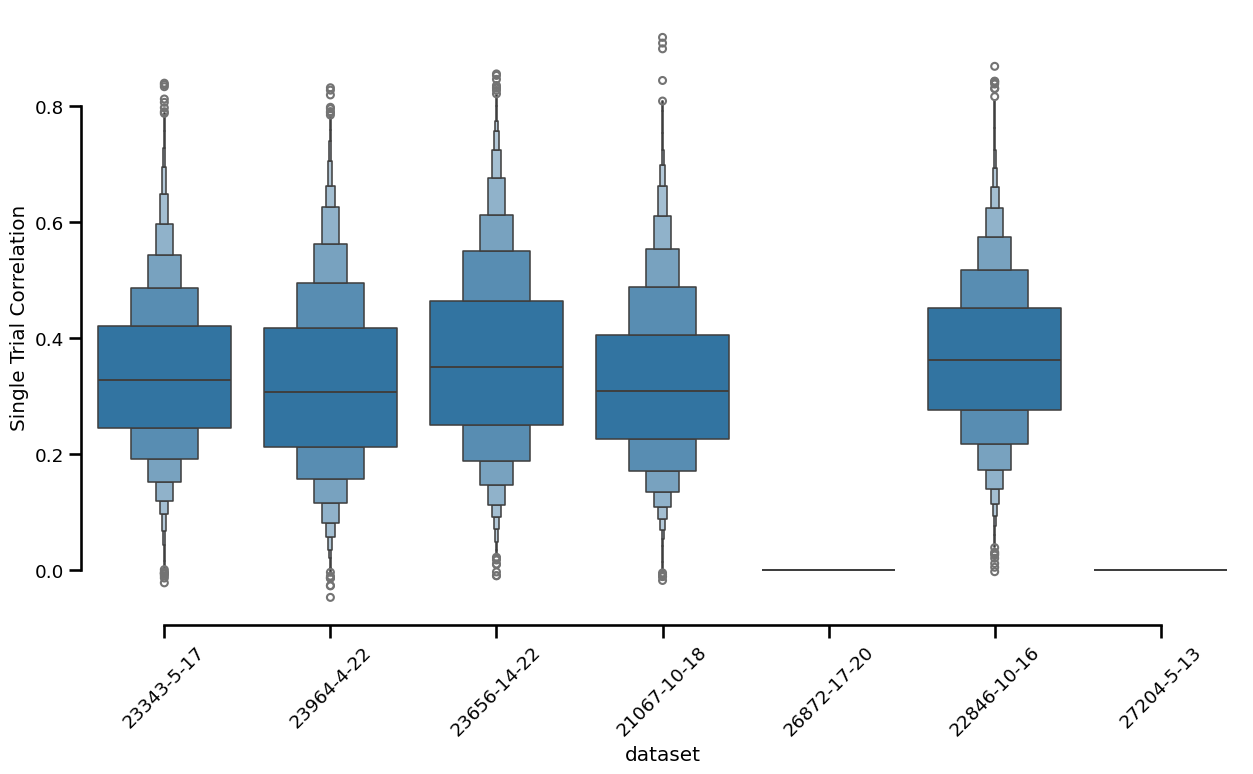

In [14]:
sns.set_context("talk", font_scale=.8)
fig = plt.figure(figsize=(15,8))
sns.boxenplot(x="dataset", y="Single Trial Correlation", data=df, )
plt.xticks(rotation = 45);
sns.despine(trim=True)

In [15]:
correlation_to_average = get_signal_correlations(model, dataloaders, tier="test", device=device, as_dict=True)

measure_attribute = "Correlation to Average"
df = get_df_for_scores(
    session_dict=correlation_to_average,
    measure_attribute=measure_attribute,
)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")


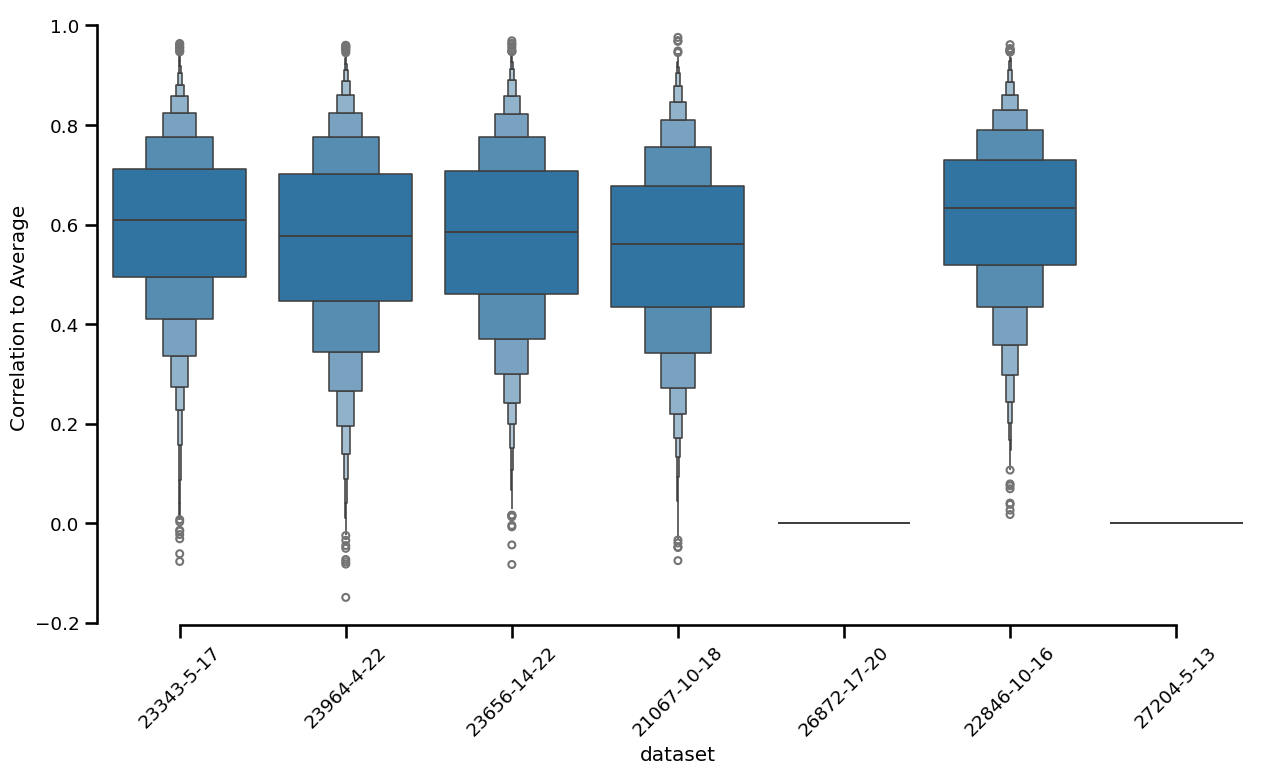

In [16]:
fig = plt.figure(figsize=(15,8))
sns.boxenplot(x="dataset", y=measure_attribute, data=df, )
plt.xticks(rotation = 45);
sns.despine(trim=True)

In [17]:
feves = get_fev(model, dataloaders, tier="test", device=device, as_dict=True)
measure_attribute = "FEVE"
df = get_df_for_scores(
    session_dict=feves,
    measure_attribute=measure_attribute,
)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/measures/np_functions.py:127: RuntimeWarning: invalid value encountered in divide
  fev = (total_var - noise_var) / total_var
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/measures/np_functions.py:130: RuntimeWarning: divide by zero encountered in divide
  fev_e = 1 - (pred_var - noise_var) / (total_var - noise_var)


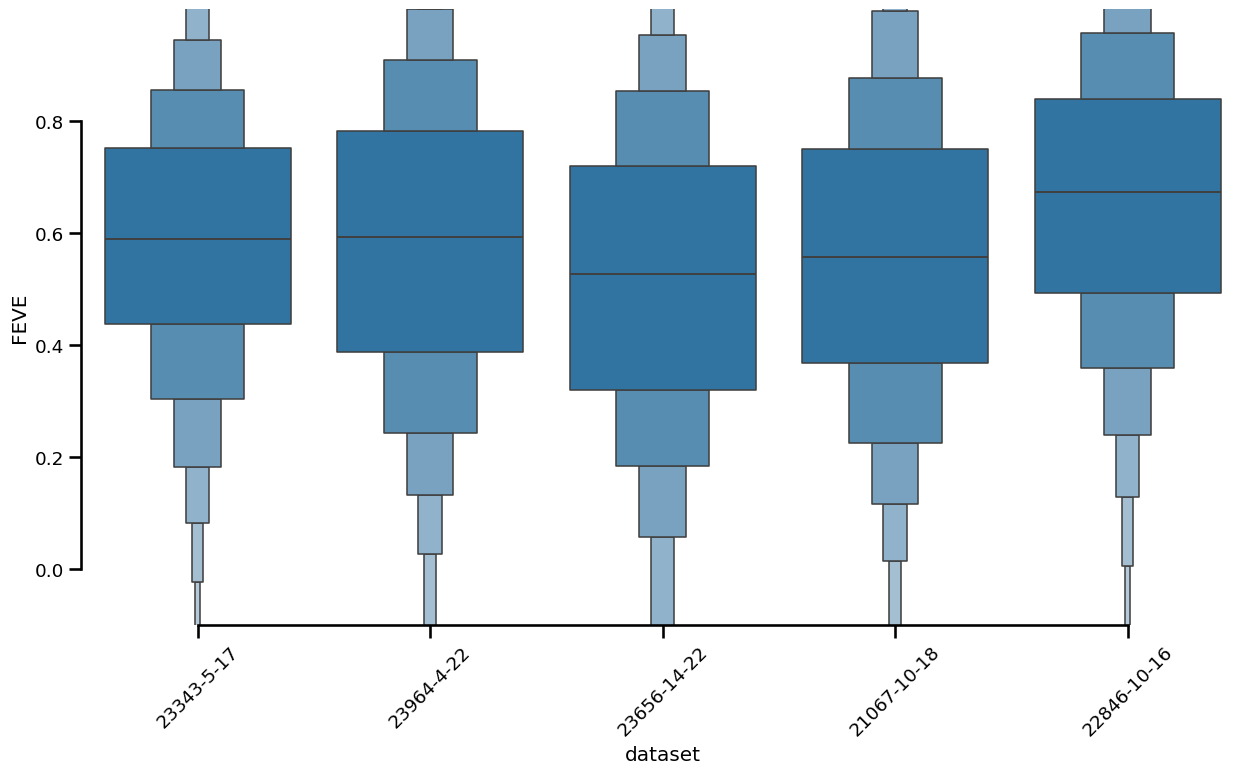

In [18]:
fig = plt.figure(figsize=(15,8))
sns.boxenplot(x="dataset", y=measure_attribute, data=df, )
plt.xticks(rotation = 45);
plt.ylim([-.1, 1])
sns.despine(trim=True)